# Kim et al. (2022): PET glycolysis with a Box–Behnken design

## 0. Reproducibility card

| Item | Record |
|---|---|
| Article | Kim, Y.; Kim, M.; Hwang, J.; Im, E.; Moon, G. D. (2022). *Optimizing PET Glycolysis with an Oyster Shell-Derived Catalyst Using Response Surface Methodology*. **Polymers, 14**, 656. |
| DOI | [10.3390/polym14040656](https://doi.org/10.3390/polym14040656) |
| Open-access route | [PubMed Central, PMCID PMC8877978](https://pmc.ncbi.nlm.nih.gov/articles/PMC8877978/) |
| Licence | [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) |
| Citation snapshot | 45 citations in [OUCI](https://ouci.dntb.gov.ua/en/works/leyOO0Wl/), retrieved 2026-08-01. Counts vary by database. |
| Reproduction level | **Level B — analytical reproduction.** The printed run matrix is complete, but refitting it does not exactly recover several printed coefficients and ANOVA quantities. |
| Core tools | `pydoe`, NumPy, pandas, SciPy, statsmodels, scikit-learn, matplotlib |
| Random seed | 20220209 |
| Reproduced | BBD geometry and randomized order; coded effects; full quadratic OLS; PRESS predicted $R^2$; lack-of-fit decomposition; surfaces and constrained predictions. |
| Not exactly reproducible | Design-Expert's undocumented desirability settings; several internally inconsistent printed values; raw confirmation replicates (only their mean is reported). |

**Evidence labels used below:** “paper” means reported by Kim et al.; “reproduction” means computed directly from the printed Table 2; “teaching analysis” means a new notebook result. No new laboratory observations are implied.

> **Practitioner reading guide.** Every case follows the same path: scientific context → evidence and provenance → design reconstruction → design diagnostics → article analysis → publication checks → a clearly labelled teaching extension → practitioner conclusions → reproducibility metadata. **Paper** denotes a published result, **reproduction** a notebook calculation from available evidence, and **teaching analysis** a new demonstration rather than new experimental evidence. Install the shared [`requirements.txt`](requirements.txt); Section 9 records the detailed environment used for this notebook's saved execution.


In [1]:
from __future__ import annotations

import hashlib
import os
import platform
import sys
import tempfile
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "mpl-kim2022"))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydoe
import scipy
from scipy import optimize, stats
import sklearn
import statsmodels
import statsmodels.api as sm
from sklearn.model_selection import LeaveOneOut

from pydoe import bbdesign

SEED = 20220209
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
warnings.filterwarnings("ignore", category=RuntimeWarning)

mpl.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (9, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 9,
})

versions = {
    "Python": platform.python_version(),
    "pydoe": getattr(pydoe, "__version__", "development checkout"),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "statsmodels": statsmodels.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": mpl.__version__,
}
pd.Series(versions, name="version").to_frame()

,version
Python,3.13.2
pydoe,1.3.1.dev11+geca1a2598
numpy,2.3.4
pandas,3.0.0
scipy,1.16.2
statsmodels,0.14.6
scikit-learn,1.9.0
matplotlib,3.11.1


## 1. Scientific context

The experimental unit is one batch glycolysis reaction: cleaned PET pieces react with ethylene glycol (EG) and a CaO-rich catalyst prepared from calcined oyster shells. The response is isolated bis(2-hydroxyethyl) terephthalate (BHET) molar yield, expressed as percent of PET repeat units. EG:PET was fixed at 5:1 by mass after preliminary one-factor-at-a-time (OFAT) work.

| Coded factor | Physical factor | Type | −1 | 0 | +1 |
|---|---|---|---:|---:|---:|
| $X_1$ | temperature (°C) | quantitative, controlled | 175 | 185 | 195 |
| $X_2$ | time (min) | quantitative, controlled | 10 | 35 | 60 |
| $X_3$ | catalyst:PET (% w/w) | quantitative, controlled | 0.2 | 0.6 | 1.0 |

A three-factor Box–Behnken design (BBD) estimates all linear terms, two-factor interactions, and pure quadratics without running the cube corners, where all factors are simultaneously extreme. Twelve edge-midpoint runs plus three centre replicates give 15 runs. The centre replicates provide two degrees of freedom for **pure error**; they are genuine repeated experiments, not repeated model fits. The paper says run order was completely randomized and supplies both standard and executed run order. No blocks or missing responses are reported.

The scientific question is whether temperature, time, catalyst loading, and their interactions can predict and improve BHET yield. Compared with OFAT, this design exposes interactions—notably temperature×time and temperature×catalyst—and provides curvature information.

## 2. Data provenance and reproduction boundary

The 15 settings and responses below are manually transcribed, at printed precision, from **Table 2** of the CC BY article. Table 1 supplies coding ranges; Tables 3–4 and Equations 4–5 supply validation targets. The supplementary archive contains characterization figures and diagnostic plots, but no higher-precision machine-readable response table. The three raw confirmation yields are not published, so only their reported mean (64.98%) can be checked.

Assertions preserve the paper's row order, bounds, factor levels, centre replication, and absence of missing values. Derived coded columns remain separate from raw values. A checksum makes later edits visible.

In [2]:
raw = pd.DataFrame(
    [
        (1, 1, 175, 10, 0.6, 0.00),
        (5, 2, 175, 35, 0.2, 0.00),
        (13, 3, 185, 35, 0.6, 16.06),
        (12, 4, 185, 60, 1.0, 39.70),
        (10, 5, 185, 60, 0.2, 20.31),
        (4, 6, 195, 60, 0.6, 64.88),
        (15, 7, 185, 35, 0.6, 14.55),
        (8, 8, 195, 35, 1.0, 57.16),
        (3, 9, 175, 60, 0.6, 14.03),
        (6, 10, 195, 35, 0.2, 22.80),
        (7, 11, 175, 35, 1.0, 12.21),
        (2, 12, 195, 10, 0.6, 20.29),
        (11, 13, 185, 10, 1.0, 6.94),
        (9, 14, 185, 10, 0.2, 0.00),
        (14, 15, 185, 35, 0.6, 13.96),
    ],
    columns=["standard_order", "run", "temperature_C", "time_min", "catalyst_pct", "yield_pct"],
)

assert raw["run"].tolist() == list(range(1, 16))
assert sorted(raw["standard_order"]) == list(range(1, 16))
assert set(raw["temperature_C"]) == {175, 185, 195}
assert set(raw["time_min"]) == {10, 35, 60}
assert set(raw["catalyst_pct"]) == {0.2, 0.6, 1.0}
assert raw.isna().sum().sum() == 0
assert raw.query("temperature_C == 185 and time_min == 35 and catalyst_pct == 0.6").shape[0] == 3

csv_bytes = raw.to_csv(index=False, lineterminator="\n").encode()
DATA_SHA256 = hashlib.sha256(csv_bytes).hexdigest()
print("Table 2 transcription SHA-256:", DATA_SHA256)
raw

Table 2 transcription SHA-256: 3ead781b5a00f596dbb3143f1d7a05ec0f4cb43d5c5e29500b51acb4558f904e


,standard_order,run,temperature_C,time_min,catalyst_pct,yield_pct
0,1,1,175,10,0.6,0.00
1,5,2,175,35,0.2,0.00
2,13,3,185,35,0.6,16.06
3,12,4,185,60,1.0,39.70
4,10,5,185,60,0.2,20.31
5,4,6,195,60,0.6,64.88
6,15,7,185,35,0.6,14.55
7,8,8,195,35,1.0,57.16
8,3,9,175,60,0.6,14.03
9,6,10,195,35,0.2,22.80


## 3. Reconstruct the design

`pydoe.bbdesign(3, center=3)` generates the nominal standard-order BBD. Physical decoding uses

$$T=185+10X_1,\qquad t=35+25X_2,\qquad C=0.6+0.4X_3.$$

We join the generated standard order to the paper's randomized run order. The assertion below is the key design-reproduction contract: every published setting must equal its generated setting exactly.

In [3]:
generated = pd.DataFrame(bbdesign(3, center=3), columns=["x1", "x2", "x3"])
generated.insert(0, "pydoe_order", np.arange(1, len(generated) + 1))
generated["temperature_C_nominal"] = 185 + 10 * generated["x1"]
generated["time_min_nominal"] = 35 + 25 * generated["x2"]
generated["catalyst_pct_nominal"] = 0.6 + 0.4 * generated["x3"]

# The paper and pydoe enumerate two edge pairs differently, so match settings rather
# than assuming that their respective standard-order labels are identical.
published = raw.copy()
published["x1"] = ((published["temperature_C"] - 185) / 10).round(12)
published["x2"] = ((published["time_min"] - 35) / 25).round(12)
published["x3"] = ((published["catalyst_pct"] - 0.6) / 0.4).round(12)
published = published.sort_values("standard_order")
published["replicate_id"] = published.groupby(["x1", "x2", "x3"]).cumcount()
generated["replicate_id"] = generated.groupby(["x1", "x2", "x3"]).cumcount()
data = published.merge(generated, on=["x1", "x2", "x3", "replicate_id"], validate="one_to_one")
data = data.sort_values("run").reset_index(drop=True)
deviations = pd.DataFrame({
    "temperature_C": data["temperature_C"] - data["temperature_C_nominal"],
    "time_min": data["time_min"] - data["time_min_nominal"],
    "catalyst_pct": data["catalyst_pct"] - data["catalyst_pct_nominal"],
})
assert np.allclose(deviations, 0)
print("Maximum absolute executed-vs-nominal deviation:")
display(deviations.abs().max().to_frame("max_abs_deviation"))
data[["run", "standard_order", "pydoe_order", "x1", "x2", "x3", "temperature_C", "time_min", "catalyst_pct", "yield_pct"]]

Maximum absolute executed-vs-nominal deviation:


,max_abs_deviation
temperature_C,0.0000e+00
time_min,0.0000e+00
catalyst_pct,5.5511e-17


,run,standard_order,pydoe_order,x1,x2,x3,temperature_C,time_min,catalyst_pct,yield_pct
0,1,1,1,-1.0,-1.0,0.0,175,10,0.6,0.00
1,2,5,5,-1.0,0.0,-1.0,175,35,0.2,0.00
2,3,13,13,0.0,0.0,0.0,185,35,0.6,16.06
3,4,12,12,0.0,1.0,1.0,185,60,1.0,39.70
4,5,10,11,0.0,1.0,-1.0,185,60,0.2,20.31
5,6,4,4,1.0,1.0,0.0,195,60,0.6,64.88
6,7,15,15,0.0,0.0,0.0,185,35,0.6,14.55
7,8,8,8,1.0,0.0,1.0,195,35,1.0,57.16
8,9,3,2,-1.0,1.0,0.0,175,60,0.6,14.03
9,10,6,7,1.0,0.0,-1.0,195,35,0.2,22.80


## 4. Understand the design

The full quadratic model has 10 coefficients (intercept, 3 linear, 3 interactions, 3 squares), leaving only 5 residual degrees of freedom. Linear and two-factor-interaction columns are mutually orthogonal here, so their estimates do not compete for the same information. Quadratic columns are correlated with the intercept and each other; consequently curvature estimates are less cleanly separated.

Rank confirms estimability, eigenvalues show weak/strong information directions, the condition number summarizes numerical stability in coded units, and leverage measures how strongly each response controls its own fitted value. These are design properties—not evidence that the response model is scientifically correct.

,value
runs,15.0000
quadratic coefficients,10.0000
matrix rank,10.0000
residual df,5.0000
condition number of X,4.2385
smallest information eigenvalue,1.6346
largest information eigenvalue,29.3654
maximum leverage,0.7500


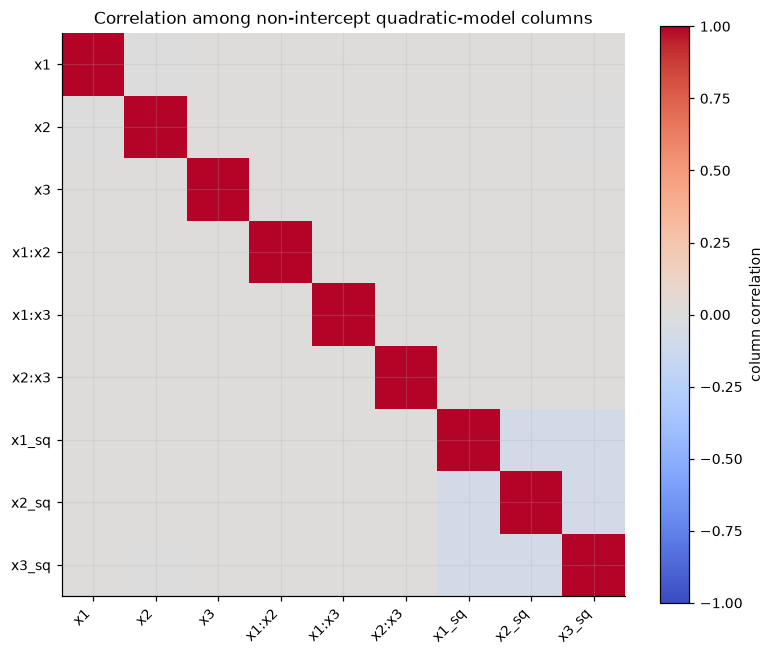

Practitioner reading: zeros mean effects are estimated independently; correlated square terms share curvature information.


In [4]:
TERMS = ["Intercept", "x1", "x2", "x3", "x1:x2", "x1:x3", "x2:x3", "x1_sq", "x2_sq", "x3_sq"]

def quadratic_matrix(points):
    z = np.asarray(points, dtype=float)
    return np.column_stack([
        np.ones(len(z)), z,
        z[:, 0] * z[:, 1], z[:, 0] * z[:, 2], z[:, 1] * z[:, 2],
        z[:, 0] ** 2, z[:, 1] ** 2, z[:, 2] ** 2,
    ])

X = quadratic_matrix(data[["x1", "x2", "x3"]])
info = X.T @ X
eigenvalues = np.linalg.eigvalsh(info)
hat = X @ np.linalg.inv(info) @ X.T
leverage = np.diag(hat)

diagnostics = pd.Series({
    "runs": len(X),
    "quadratic coefficients": X.shape[1],
    "matrix rank": np.linalg.matrix_rank(X),
    "residual df": len(X) - np.linalg.matrix_rank(X),
    "condition number of X": np.linalg.cond(X),
    "smallest information eigenvalue": eigenvalues.min(),
    "largest information eigenvalue": eigenvalues.max(),
    "maximum leverage": leverage.max(),
}, name="value")
display(diagnostics.to_frame())

corr = pd.DataFrame(X[:, 1:], columns=TERMS[1:]).corr()
fig, ax = plt.subplots(figsize=(7.2, 6))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.index)
ax.set_title("Correlation among non-intercept quadratic-model columns")
fig.colorbar(image, ax=ax, label="column correlation")
fig.tight_layout()
plt.show()
print("Practitioner reading: zeros mean effects are estimated independently; correlated square terms share curvature information.")

## 5. Reproduce the article analysis

We start with the paper's full coded quadratic model and ordinary least squares. `statsmodels` supplies coefficient uncertainty, overall $F$ testing, residuals, leverage, and influence. The printed paper appears to use partial one-degree-of-freedom sums of squares for individual terms; below they are reproduced by dropping one term from the full model at a time. All tests assume independent, constant-variance, approximately normal errors and a correctly specified mean model.

In [5]:
y = data["yield_pct"].to_numpy()
X_df = pd.DataFrame(X, columns=TERMS)
full_fit = sm.OLS(y, X_df).fit()

coefficient_table = pd.DataFrame({
    "estimate": full_fit.params,
    "std_error": full_fit.bse,
    "t": full_fit.tvalues,
    "p_value": full_fit.pvalues,
    "ci_low_95": full_fit.conf_int()[0],
    "ci_high_95": full_fit.conf_int()[1],
})
print(f"R²={full_fit.rsquared:.6f}; adjusted R²={full_fit.rsquared_adj:.6f}; model F={full_fit.fvalue:.3f}; p={full_fit.f_pvalue:.6g}")
coefficient_table

R²=0.988980; adjusted R²=0.969143; model F=49.856; p=0.000230992


,estimate,std_error,t,p_value,ci_low_95,ci_high_95
Intercept,14.8567,1.9806,7.5012,6.6576e-04,9.7654,19.9479
x1,17.3612,1.2128,14.3144,2.9991e-05,14.2435,20.4790
x2,13.9612,1.2128,11.5111,8.6741e-05,10.8435,17.0790
x3,9.1125,1.2128,7.5133,6.6079e-04,5.9948,12.2302
x1:x2,7.6400,1.7152,4.4542,6.6761e-03,3.2309,12.0491
x1:x3,5.5375,1.7152,3.2284,2.3246e-02,1.1284,9.9466
x2:x3,3.1125,1.7152,1.8146,1.2930e-01,-1.2966,7.5216
x1_sq,8.1242,1.7853,4.5507,6.1087e-03,3.5350,12.7133
x2_sq,1.8192,1.7853,1.0190,3.5495e-01,-2.7700,6.4083
x3_sq,0.0617,1.7853,0.0345,9.7378e-01,-4.5275,4.6508


In [6]:
def press_r2(fit, response):
    influence = fit.get_influence()
    press = np.sum((fit.resid / (1 - influence.hat_matrix_diag)) ** 2)
    sst = np.sum((response - np.mean(response)) ** 2)
    return press, 1 - press / sst

def fit_statistics(columns):
    fit = sm.OLS(y, X_df[columns]).fit()
    press, predicted_r2 = press_r2(fit, y)
    return fit, {"R2": fit.rsquared, "adjusted_R2": fit.rsquared_adj, "predicted_R2_PRESS": predicted_r2, "PRESS": press}

model_columns = {
    "Linear": TERMS[:4],
    "2FI": TERMS[:7],
    "Quadratic": TERMS,
}
fits = {name: fit_statistics(cols) for name, cols in model_columns.items()}
fit_table = pd.DataFrame({name: stats_ for name, (_, stats_) in fits.items()}).T
fit_table

,R2,adjusted_R2,predicted_R2_PRESS,PRESS
Linear,0.8681,0.8321,0.7338,1421.0951
2FI,0.9421,0.8986,0.7601,1281.0978
Quadratic,0.9890,0.9691,0.8297,909.1830


In [7]:
full_sse = np.sum(full_fit.resid ** 2)
mse = full_fit.mse_resid
partial_rows = []
for term in TERMS[1:]:
    reduced_cols = [c for c in TERMS if c != term]
    reduced_fit = sm.OLS(y, X_df[reduced_cols]).fit()
    ss = np.sum(reduced_fit.resid ** 2) - full_sse
    f_value = ss / mse
    partial_rows.append((term, ss, 1, ss, f_value, stats.f.sf(f_value, 1, full_fit.df_resid)))

partial_anova = pd.DataFrame(partial_rows, columns=["term", "sum_sq", "df", "mean_sq", "F", "p_value"]).set_index("term")
model_ss = np.sum((full_fit.fittedvalues - y.mean()) ** 2)
model_row = pd.DataFrame({
    "sum_sq": [model_ss], "df": [9], "mean_sq": [model_ss / 9],
    "F": [full_fit.fvalue], "p_value": [full_fit.f_pvalue],
}, index=["Model"])
display(pd.concat([model_row, partial_anova]))
print("Convention: each term SS is the extra SS after dropping that one term from the full hierarchical quadratic model (partial/Type III-style test in coded variables).")

,sum_sq,df,mean_sq,F,p_value
Model,5280.3896,9,586.7100,49.8563,2.3099e-04
x1,2411.3040,1,2411.3040,204.9031,2.9991e-05
x2,1559.3320,1,1559.3320,132.5059,8.6741e-05
x3,664.3012,1,664.3012,56.4497,6.6079e-04
x1:x2,233.4784,1,233.4784,19.8401,6.6761e-03
x1:x3,122.6556,1,122.6556,10.4228,2.3246e-02
x2:x3,38.7506,1,38.7506,3.2929,1.2930e-01
x1_sq,243.7000,1,243.7000,20.7087,6.1087e-03
x2_sq,12.2192,1,12.2192,1.0383,3.5495e-01
x3_sq,0.0140,1,0.0140,0.0012,9.7378e-01


Convention: each term SS is the extra SS after dropping that one term from the full hierarchical quadratic model (partial/Type III-style test in coded variables).


In [8]:
# Equation 5 retains hierarchy while removing x2:x3, x2², and x3².
reduced_terms = ["Intercept", "x1", "x2", "x3", "x1:x2", "x1:x3", "x1_sq"]
reduced_fit = sm.OLS(y, X_df[reduced_terms]).fit()
paper_reduced = pd.Series({
    "Intercept": 16.20, "x1": 17.36, "x2": 13.96, "x3": 9.11,
    "x1:x2": 7.64, "x1:x3": 5.54, "x1_sq": 7.72,
}, name="paper_Equation_5")
reduced_comparison = pd.concat([paper_reduced, reduced_fit.params.rename("Table_2_refit")], axis=1)
reduced_comparison["absolute_difference"] = (reduced_comparison["Table_2_refit"] - reduced_comparison["paper_Equation_5"]).abs()
display(reduced_comparison)
print(f"Reduced hierarchical model: R²={reduced_fit.rsquared:.4f}, adjusted R²={reduced_fit.rsquared_adj:.4f}")
print("The retained interactions have both parent main effects, so this particular reduction respects hierarchy; selection uncertainty and lack of fit still remain.")

,paper_Equation_5,Table_2_refit,absolute_difference
Intercept,16.20,15.9314,0.2686
x1,17.36,17.3612,0.0012
x2,13.96,13.9612,0.0012
x3,9.11,9.1125,0.0025
x1:x2,7.64,7.6400,0.0000
x1:x3,5.54,5.5375,0.0025
x1_sq,7.72,7.9898,0.2698


Reduced hierarchical model: R²=0.9794, adjusted R²=0.9640
The retained interactions have both parent main effects, so this particular reduction respects hierarchy; selection uncertainty and lack of fit still remain.


### Pure error versus lack of fit

Residual error mixes two different things. **Pure error** is variation among replicated centre runs. **Lack of fit** is the remaining discrepancy between setting means and the quadratic surface. A significant lack-of-fit test says the quadratic's systematic error is large compared with repeatability at the centre. With only one replicated setting, this test relies on the centre variance being representative across the whole region.

In [9]:
setting_cols = ["x1", "x2", "x3"]
grouped = data.groupby(setting_cols, sort=False)["yield_pct"]
pure_error_ss = grouped.apply(lambda s: np.sum((s - s.mean()) ** 2)).sum()
pure_error_df = grouped.size().sub(1).sum()
lof_ss = full_sse - pure_error_ss
lof_df = int(full_fit.df_resid - pure_error_df)
lof_ms = lof_ss / lof_df
pure_error_ms = pure_error_ss / pure_error_df
lof_f = lof_ms / pure_error_ms
lof_p = stats.f.sf(lof_f, lof_df, pure_error_df)

error_decomposition = pd.DataFrame({
    "sum_sq": [full_sse, lof_ss, pure_error_ss],
    "df": [int(full_fit.df_resid), lof_df, pure_error_df],
    "mean_sq": [full_sse / full_fit.df_resid, lof_ms, pure_error_ms],
    "F_vs_pure_error": [np.nan, lof_f, np.nan],
    "p_value": [np.nan, lof_p, np.nan],
}, index=["Residual", "Lack of fit", "Pure error"])
error_decomposition

,sum_sq,df,mean_sq,F_vs_pure_error,p_value
Residual,58.8401,5,11.7680,NaN,NaN
Lack of fit,56.4940,3,18.8313,16.0535,0.0592
Pure error,2.3461,2,1.1730,NaN,NaN


### Residual, leverage, and influence diagnostics

With 15 observations, visual diagnostics have low power. They can reveal gross problems but cannot prove normality or equal variance. Internally studentized residuals divide by their estimated local standard deviation. Cook's distance summarizes how much the entire fit changes when a run is deleted.

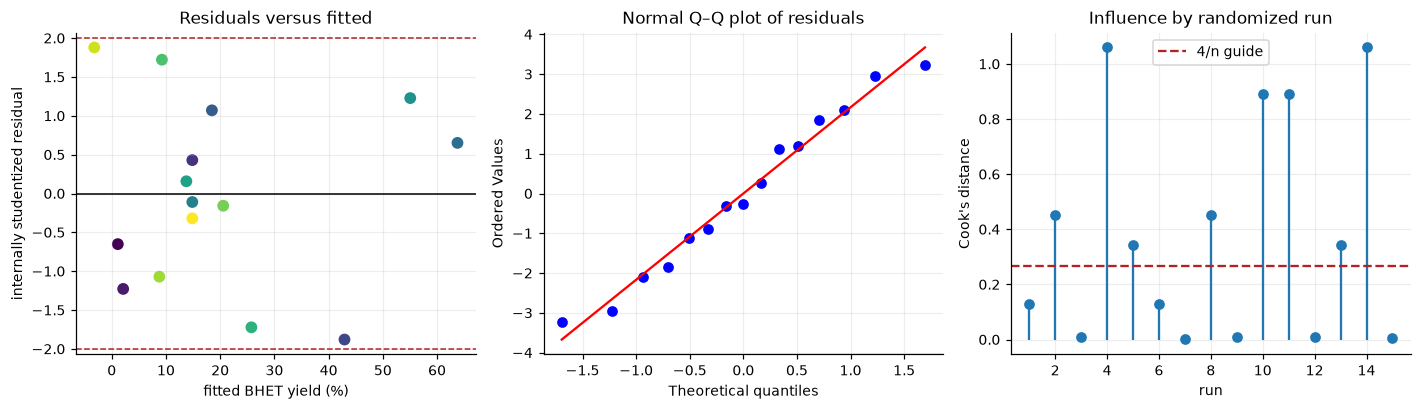

,run,fitted_pct,residual_pct,leverage,cooks_d
3,4,42.9237,-3.2237,0.75,1.0597
13,14,-3.2237,3.2237,0.75,1.0597
10,11,9.2562,2.9538,0.75,0.8897
9,10,25.7537,-2.9537,0.75,0.8897
1,2,2.1063,-2.1063,0.75,0.4524


In [10]:
influence = full_fit.get_influence()
studentized = influence.resid_studentized_internal
cooks_d = influence.cooks_distance[0]
fitted = full_fit.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].scatter(fitted, studentized, c=data["run"], cmap="viridis", s=45)
axes[0].axhline(0, color="black", lw=1)
axes[0].axhline(2, color="firebrick", ls="--", lw=1)
axes[0].axhline(-2, color="firebrick", ls="--", lw=1)
axes[0].set(title="Residuals versus fitted", xlabel="fitted BHET yield (%)", ylabel="internally studentized residual")

stats.probplot(full_fit.resid, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q–Q plot of residuals")

axes[2].stem(data["run"], cooks_d, basefmt=" ")
axes[2].axhline(4 / len(data), color="firebrick", ls="--", label="4/n guide")
axes[2].set(title="Influence by randomized run", xlabel="run", ylabel="Cook's distance")
axes[2].legend()
fig.tight_layout()
plt.show()

pd.DataFrame({"run": data["run"], "fitted_pct": fitted, "residual_pct": full_fit.resid,
              "leverage": influence.hat_matrix_diag, "cooks_d": cooks_d}).sort_values("cooks_d", ascending=False).head()

### Response surfaces

These are **reproduction-derived** surfaces from the full Table 2 fit, not digitized copies of Figure 5. Each panel fixes the omitted factor at its centre. Observations in that slice are overlaid. Smooth colour bands are predictions, not additional data.

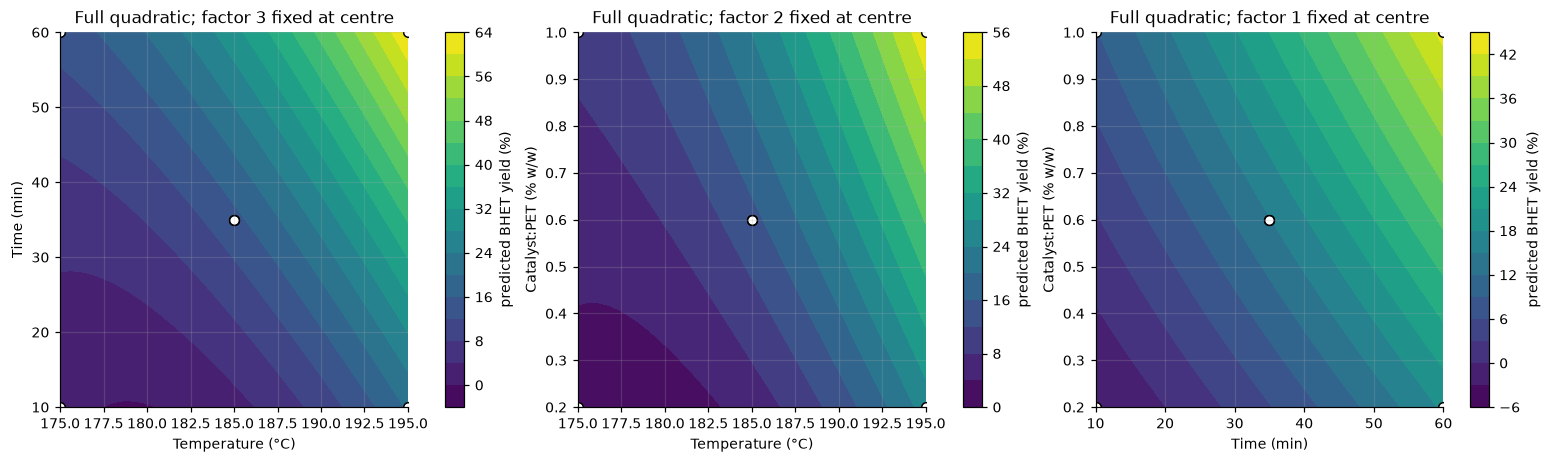

In [11]:
grid = np.linspace(-1, 1, 101)
pairs = [(0, 1, 2), (0, 2, 1), (1, 2, 0)]
labels = [("Temperature (°C)", "Time (min)"), ("Temperature (°C)", "Catalyst:PET (% w/w)"), ("Time (min)", "Catalyst:PET (% w/w)")]
decode = [lambda z: 185 + 10 * z, lambda z: 35 + 25 * z, lambda z: 0.6 + 0.4 * z]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.1), constrained_layout=True)
for ax, (a, b, fixed), (xlabel, ylabel) in zip(axes, pairs, labels):
    ga, gb = np.meshgrid(grid, grid)
    pts = np.zeros((ga.size, 3))
    pts[:, a], pts[:, b] = ga.ravel(), gb.ravel()
    pred = full_fit.predict(pd.DataFrame(quadratic_matrix(pts), columns=TERMS)).to_numpy().reshape(ga.shape)
    contour = ax.contourf(decode[a](ga), decode[b](gb), pred, levels=16, cmap="viridis")
    slice_mask = np.isclose(data[["x1", "x2", "x3"]].to_numpy()[:, fixed], 0)
    observed = data.loc[slice_mask]
    ax.scatter(decode[a](observed[["x1", "x2", "x3"]].to_numpy()[:, a]),
               decode[b](observed[["x1", "x2", "x3"]].to_numpy()[:, b]),
               c="white", edgecolor="black", s=40, label="observed slice")
    ax.set(xlabel=xlabel, ylabel=ylabel, title=f"Full quadratic; factor {fixed + 1} fixed at centre")
    fig.colorbar(contour, ax=ax, label="predicted BHET yield (%)")
plt.show()

## 6. Validate against the paper

Absolute differences below are based solely on values printed in Tables 2–4 and Equations 4–5. Relative differences are omitted when the published target is zero. Tolerances reflect printed precision, not a post-hoc attempt to force agreement.

In [12]:
paper_coefficients = {
    "Intercept": 15.49, "x1": 17.36, "x2": 13.96, "x3": 9.11,
    "x1:x2": 7.64, "x1:x3": 5.54, "x2:x3": 3.11,
    "x1_sq": 7.81, "x2_sq": 1.50, "x3_sq": -0.025,
}
validation_items = [
    ("R²", 0.9891, full_fit.rsquared, 0.001),
    ("Adjusted R²", 0.9696, full_fit.rsquared_adj, 0.002),
    ("Predicted R² (PRESS)", 0.8297, press_r2(full_fit, y)[1], 0.001),
    ("Model SS", 5260.9, model_ss, 1.0),
    ("Residual SS", 57.78, full_sse, 0.2),
    ("Pure-error SS", 1.35, pure_error_ss, 0.05),
    ("Lack-of-fit F", 27.88, lof_f, 0.5),
]
validation_items += [(f"Coefficient {term}", published, full_fit.params[term], 0.08)
                     for term, published in paper_coefficients.items()]
validation = pd.DataFrame(validation_items, columns=["target", "published", "reproduced", "tolerance"])
validation["abs_difference"] = (validation["reproduced"] - validation["published"]).abs()
validation["relative_difference"] = validation["abs_difference"] / validation["published"].abs().replace(0, np.nan)
validation["within_tolerance"] = validation["abs_difference"] <= validation["tolerance"]
validation

,target,published,reproduced,tolerance,abs_difference,relative_difference,within_tolerance
0,R²,0.9891,0.9890,0.001,1.2033e-04,1.2166e-04,True
1,Adjusted R²,0.9696,0.9691,0.002,4.5693e-04,4.7126e-04,True
2,Predicted R² (PRESS),0.8297,0.8297,0.001,1.6438e-05,1.9812e-05,True
3,Model SS,5260.9000,5280.3896,1.000,1.9490e+01,3.7046e-03,False
4,Residual SS,57.7800,58.8401,0.200,1.0601e+00,1.8347e-02,False
5,Pure-error SS,1.3500,2.3461,0.050,9.9607e-01,7.3783e-01,False
6,Lack-of-fit F,27.8800,16.0535,0.500,1.1826e+01,4.2419e-01,False
7,Coefficient Intercept,15.4900,14.8567,0.080,6.3333e-01,4.0887e-02,False
8,Coefficient x1,17.3600,17.3612,0.080,1.2500e-03,7.2005e-05,True
9,Coefficient x2,13.9600,13.9612,0.080,1.2500e-03,8.9542e-05,True


**Discrepancy assessment.** The linear and interaction coefficients and PRESS predicted $R^2$ agree to rounding, which strongly supports the coding and run transcription. The printed Table 2 values imply an intercept of 14.8567 (the centre-run mean), not 15.49, and imply pure-error SS 2.3461, not 1.35. Several printed quadratic coefficients and sums of squares also differ. Because a full quadratic must predict the average of identical centre rows at its intercept, this conflict cannot be explained by sums-of-squares convention. Likely causes include higher-precision/unpublished responses, transcription into Design-Expert differing from printed Table 2, or reporting errors. We do not “correct” the source.

The paper's own lack-of-fit test is significant ($p=0.0348$); the direct Table 2 calculation is also concerning. Therefore, high $R^2$ and attractive residual plots are not enough to claim that the quadratic is an accurate mean model throughout the region.

## 7. Go beyond the paper

### 7.1 Optimization, interpolation, and extrapolation

The article's numerical optimum combines response yield with economic/environmental preferences: temperature and time were constrained “in range,” while catalyst was set to “maximize.” The desirability weights, importance settings, and ramps are not reported, so the Design-Expert optimum cannot be regenerated uniquely.

We instead answer two transparent questions: (1) where does the fitted response alone reach its constrained maximum over the factor cube, and (2) what does the directly fitted model predict at the reported confirmation setting? A 3-factor BBD occupies the cuboctahedral hull $|X_1|+|X_2|+|X_3|\le2$. Points inside the factor cube but outside that hull require model-based extrapolation between unobserved corners.

In [13]:
def predict_full(z):
    row = pd.DataFrame(quadratic_matrix(np.atleast_2d(z)), columns=TERMS)
    return float(full_fit.predict(row).iloc[0])

result = optimize.differential_evolution(lambda z: -predict_full(z), bounds=[(-1, 1)] * 3, seed=SEED, polish=True)
response_optimum = result.x
confirmation = np.array([1.0, (45 - 35) / 25, 1.0])

def physical(z):
    return {"temperature_C": 185 + 10*z[0], "time_min": 35 + 25*z[1], "catalyst_pct": 0.6 + 0.4*z[2]}

optimization_summary = pd.DataFrame([
    {"case": "Response-only maximum of Table 2 fit", **physical(response_optimum),
     "predicted_yield_pct": predict_full(response_optimum), "L1_coded": np.abs(response_optimum).sum()},
    {"case": "Paper confirmation setting", **physical(confirmation),
     "predicted_yield_pct": predict_full(confirmation), "L1_coded": np.abs(confirmation).sum()},
]).set_index("case")
optimization_summary["inside_BBD_convex_hull"] = optimization_summary["L1_coded"] <= 2 + 1e-12
optimization_summary

,temperature_C,time_min,catalyst_pct,predicted_yield_pct,L1_coded,inside_BBD_convex_hull
case,,,,,,
Response-only maximum of Table 2 fit,195.0,60.0,1.0,81.5867,3.0,False
Paper confirmation setting,195.0,45.0,1.0,65.2303,2.4,False


In [14]:
x0 = quadratic_matrix(np.atleast_2d(confirmation))[0]
mean_pred = predict_full(confirmation)
se_mean = np.sqrt(full_fit.mse_resid * (x0 @ np.linalg.inv(info) @ x0))
se_prediction = np.sqrt(full_fit.mse_resid * (1 + x0 @ np.linalg.inv(info) @ x0))
tcrit = stats.t.ppf(0.975, full_fit.df_resid)
confirmation_uncertainty = pd.Series({
    "Table 2 fit prediction (%)": mean_pred,
    "paper model prediction (%)": 64.88,
    "paper confirmation mean (%)": 64.98,
    "95% CI for fitted mean, lower (%)": mean_pred - tcrit * se_mean,
    "95% CI for fitted mean, upper (%)": mean_pred + tcrit * se_mean,
    "95% prediction interval, lower (%)": mean_pred - tcrit * se_prediction,
    "95% prediction interval, upper (%)": mean_pred + tcrit * se_prediction,
    "coded L1 distance (BBD hull boundary = 2)": np.abs(confirmation).sum(),
}, name="value")
confirmation_uncertainty.to_frame()

,value
Table 2 fit prediction (%),65.2303
paper model prediction (%),64.8800
paper confirmation mean (%),64.9800
"95% CI for fitted mean, lower (%)",57.2600
"95% CI for fitted mean, upper (%)",73.2006
"95% prediction interval, lower (%)",53.3439
"95% prediction interval, upper (%)",77.1168
coded L1 distance (BBD hull boundary = 2),2.4000


The confirmation condition is inside every stated factor range but outside the convex hull of the 15 BBD points. That distinction matters: “within the box” is not automatically interpolation. Confirmation experiments are therefore especially valuable, but their raw replicate values are needed to assess variance and agreement independently.

### 7.2 Equal-budget comparison with random designs

This teaching simulation compares the fixed 15-run BBD with 500 uniform random 15-run designs for the *same full quadratic model*. For each design, $D$ information is the geometric mean eigenvalue of $X^TX/n$ (larger means a smaller joint coefficient-confidence volume). Maximum scaled prediction variance is evaluated on a common grid (smaller is better). Random designs use the same run budget but usually have no replication, so they cannot estimate pure error directly.

,BBD,random median,random 10th percentile,random 90th percentile
metric,,,,
D information (larger better),0.3664,0.0971,0.0667,0.1295
maximum scaled prediction variance (smaller better),20.9375,814.3225,314.6235,2801.9317


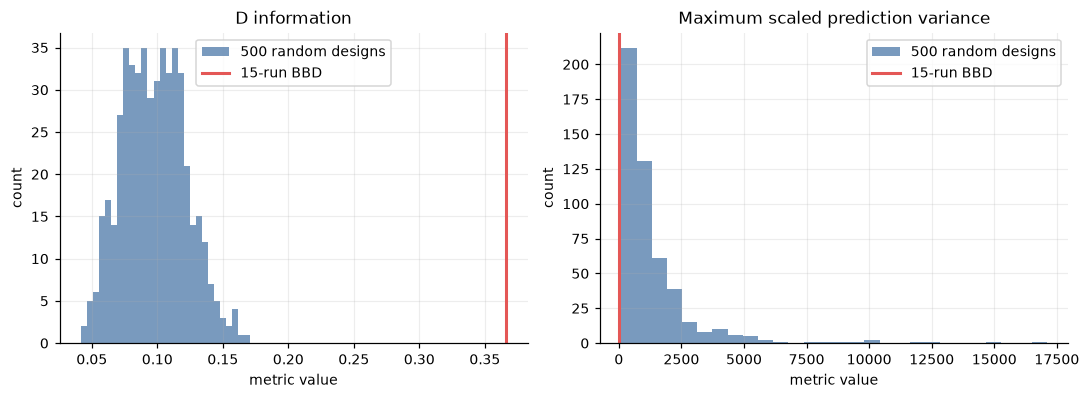

In [15]:
def design_metrics(points, evaluation_points):
    Xm = quadratic_matrix(points)
    if np.linalg.matrix_rank(Xm) < Xm.shape[1]:
        return np.nan, np.inf
    normalized_info = Xm.T @ Xm / len(Xm)
    sign, logdet = np.linalg.slogdet(normalized_info)
    d_information = np.exp(logdet / Xm.shape[1]) if sign > 0 else np.nan
    inv = np.linalg.inv(Xm.T @ Xm)
    Xe = quadratic_matrix(evaluation_points)
    scaled_variance = len(Xm) * np.einsum("ij,jk,ik->i", Xe, inv, Xe)
    return d_information, scaled_variance.max()

axis = np.linspace(-1, 1, 11)
evaluation_grid = np.array(np.meshgrid(axis, axis, axis)).reshape(3, -1).T
bbd_metrics = design_metrics(data[["x1", "x2", "x3"]].to_numpy(), evaluation_grid)
random_metrics = np.array([design_metrics(rng.uniform(-1, 1, size=(15, 3)), evaluation_grid) for _ in range(500)])

comparison = pd.DataFrame({
    "metric": ["D information (larger better)", "maximum scaled prediction variance (smaller better)"],
    "BBD": bbd_metrics,
    "random median": np.nanmedian(random_metrics, axis=0),
    "random 10th percentile": np.nanpercentile(random_metrics, 10, axis=0),
    "random 90th percentile": np.nanpercentile(random_metrics, 90, axis=0),
}).set_index("metric")
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
metric_titles = ["D information", "Maximum scaled prediction variance"]
for j, ax in enumerate(axes):
    finite = random_metrics[np.isfinite(random_metrics[:, j]), j]
    ax.hist(finite, bins=28, color="#4c78a8", alpha=0.75, label="500 random designs")
    ax.axvline(bbd_metrics[j], color="#e45756", lw=2, label="15-run BBD")
    ax.set(title=metric_titles[j], xlabel="metric value", ylabel="count")
    ax.legend()
fig.tight_layout()
plt.show()

### 7.3 Sensitivity to one influential observation

A small saturated-near design can be fragile. We add 5 yield percentage points to each run in turn, refit the same quadratic, and record the change in the confirmation prediction. This is a hypothetical perturbation—not a claim that any observation is wrong. The calculation isolates response-model sensitivity while keeping the design fixed.

In [16]:
baseline_confirmation = predict_full(confirmation)
perturbation_rows = []
for i in range(len(data)):
    perturbed_y = y.copy()
    perturbed_y[i] += 5.0
    perturbed_fit = sm.OLS(perturbed_y, X_df).fit()
    changed = float(perturbed_fit.predict(pd.DataFrame(quadratic_matrix([confirmation]), columns=TERMS)).iloc[0])
    perturbation_rows.append((int(data.loc[i, "run"]), changed - baseline_confirmation, leverage[i], cooks_d[i]))
sensitivity = pd.DataFrame(perturbation_rows, columns=["run_perturbed", "change_in_confirmation_prediction_pct_point", "leverage", "observed_cooks_d"])
sensitivity = sensitivity.reindex(sensitivity["change_in_confirmation_prediction_pct_point"].abs().sort_values(ascending=False).index)
sensitivity

,run_perturbed,change_in_confirmation_prediction_pct_point,leverage,observed_cooks_d
7,8,3.6500,0.7500,0.4524
5,6,1.4750,0.7500,0.1273
3,4,1.4750,0.7500,1.0597
1,2,1.1500,0.7500,0.4524
4,5,-0.7750,0.7500,0.3438
8,9,-0.7750,0.7500,0.0074
13,14,-0.2750,0.7500,1.0597
0,1,-0.2750,0.7500,0.1273
2,3,-0.1333,0.3333,0.0092
6,7,-0.1333,0.3333,0.0006


## 8. Practitioner conclusions

- **What DoE made possible.** Fifteen structured runs estimated three main effects, three interactions, and three curvature terms while reserving centre replication for pure error. Temperature×time and temperature×catalyst effects would be invisible to an ordinary OFAT path.
- **What the design supports.** The complete quadratic model is full rank in coded variables. Linear and interaction columns are especially clean; square terms share information. Only five residual degrees of freedom remain, so term tests and diagnostics are intrinsically uncertain.
- **What is fitted versus supported.** A quadratic can be fitted, but significant lack of fit warns that it may not describe the mean response adequately. High $R^2$ is not a substitute for that test.
- **Where prediction is trustworthy.** Confidence is strongest near sampled edge midpoints and the replicated centre. The reported confirmation point is inside the factor ranges but outside the BBD convex hull, so its prediction is extrapolative in design geometry.
- **Design limitation versus model limitation.** Sparse coverage near cube corners is a design limitation. Systematic departure from a quadratic and sensitivity to single observations are response-model limitations. More replication across the region would also test constant variance better than centre-only replication.
- **Why exact equality fails.** Table 2 reproduces key linear/interaction coefficients and predicted $R^2$, yet cannot produce several printed intercept, quadratic, and ANOVA values. This is a source-reporting inconsistency, not justification to modify data silently.
- **Mistakes to avoid.** Do not ignore hierarchy during term reduction, call every within-range point interpolation, interpret a non-significant residual plot as proof, confuse confirmation replicates with model residuals, or optimize an undocumented desirability function as though it were uniquely reproducible.

## 9. Reproducibility metadata

The final cell records the execution environment and fixed seed. The data checksum refers to the exact comma-separated representation created from the manual Table 2 transcription above. Execution from a fresh kernel is part of the repository quality gate.

In [17]:
metadata = pd.Series({
    "execution_date": "2026-08-01",
    "random_seed": SEED,
    "table2_sha256": DATA_SHA256,
    "notebook": "kim2022.ipynb",
    **versions,
}, name="value")
metadata.to_frame()

,value
execution_date,2026-08-01
random_seed,20220209
table2_sha256,3ead781b5a00f596dbb3143f1d7a05ec0f4cb43d5c5e29...
notebook,kim2022.ipynb
Python,3.13.2
pydoe,1.3.1.dev11+geca1a2598
numpy,2.3.4
pandas,3.0.0
scipy,1.16.2
statsmodels,0.14.6
